# CustIntel — End-to-End Notebook

This notebook walks through the complete project in beginner-friendly steps.

**Pipeline**

`Raw CSV/JSON → Cleaning → SQLite Star Schema → EDA → LTV/Churn ML → PyTorch Next Category → Sentiment → Chatbot → Streamlit`

> The supplied project brief specifies Olist or similar open-source e-commerce data. Because the uploaded brief does not include the actual Olist files, this notebook uses the reproducible demo data generated by `src/generate_demo_data.py`.


In [5]:


import sys
from pathlib import Path

# Get the current notebook working directory
CURRENT_DIR = Path.cwd()

# Find the project root by looking for the "src" folder
PROJECT_ROOT = CURRENT_DIR

while PROJECT_ROOT != PROJECT_ROOT.parent:
    if (PROJECT_ROOT / "src").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

# Add the PROJECT ROOT to Python's import path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Current directory :", CURRENT_DIR)
print("Project root      :", PROJECT_ROOT)
print("src folder exists :", (PROJECT_ROOT / "src").is_dir())

# ============================================================
# IMPORT PROJECT MODULES
# ============================================================

from src.generate_demo_data import generate_data
from src.database import query_dataframe
from src.features import build_customer_features

print("✅ Project modules imported successfully!")

Current directory : C:\Users\HP\GUVI CLASS\AIML_Projects\AIML_Projects\CustIntel_Portfolio\CustIntel\notebooks
Project root      : C:\Users\HP\GUVI CLASS\AIML_Projects\AIML_Projects\CustIntel_Portfolio\CustIntel
src folder exists : True
✅ Project modules imported successfully!


## 1. Generate demo CSV/JSON data

In [6]:
# This creates customers, products, orders, reviews, and browsing events.
generate_data()

from src.config import RAW_DIR
print("Raw data folder:", RAW_DIR)


Created demo data in: C:\Users\HP\GUVI CLASS\AIML_Projects\AIML_Projects\CustIntel_Portfolio\CustIntel\data\raw
Raw data folder: C:\Users\HP\GUVI CLASS\AIML_Projects\AIML_Projects\CustIntel_Portfolio\CustIntel\data\raw


## 2. Inspect the raw data

In [7]:
import pandas as pd
from src.config import RAW_DIR

orders = pd.read_csv(RAW_DIR / "orders.csv")
customers = pd.read_csv(RAW_DIR / "customers.csv")
reviews = pd.read_csv(RAW_DIR / "reviews.csv")
browsing = pd.read_csv(RAW_DIR / "browsing_events.csv")

display(customers.head())
display(orders.head())
display(reviews.head())
display(browsing.head())


,customer_id,customer_city,customer_state,signup_date
0,CUST_00001,Curitiba,SC,2022-02-14
1,CUST_00002,Rio de Janeiro,BA,2023-01-22
2,CUST_00003,Rio de Janeiro,PE,2022-11-24
3,CUST_00004,Belo Horizonte,PE,2022-08-08
4,CUST_00005,Porto Alegre,BA,2022-08-05


,order_id,customer_id,product_id,order_status,order_purchase_date,price,freight_value,quantity
0,ORD_000001,CUST_00001,PROD_0139,delivered,2023-01-02,142.28,7.53,1
1,ORD_000002,CUST_00001,PROD_0129,delivered,2024-01-20,135.28,9.34,1
2,ORD_000003,CUST_00001,PROD_0131,delivered,2023-01-23,136.64,7.45,1
3,ORD_000004,CUST_00001,PROD_0024,delivered,2024-04-05,150.05,7.15,1
4,ORD_000005,CUST_00001,PROD_0250,delivered,2024-05-05,166.99,6.85,2


,review_id,order_id,review_score,review_comment_message,review_date
0,REV_000001,ORD_008383,2,Not very happy with the purchase.,2023-04-24
1,REV_000002,ORD_005903,4,Happy with the purchase and quality.,2024-07-25
2,REV_000003,ORD_027444,1,Terrible experience. The product stopped working.,2024-01-06
3,REV_000004,ORD_026767,2,Quality is below expectations.,2023-09-24
4,REV_000005,ORD_019547,4,Happy with the purchase and quality.,2023-05-14


,event_id,customer_id,event_time,product_category
0,EVT_0000001,CUST_00001,2024-01-01T00:00:00,health_beauty
1,EVT_0000002,CUST_00001,2024-01-01T02:00:00,watches_gifts
2,EVT_0000003,CUST_00001,2024-01-01T04:00:00,health_beauty
3,EVT_0000004,CUST_00001,2024-01-01T06:00:00,watches_gifts
4,EVT_0000005,CUST_00001,2024-01-01T08:00:00,health_beauty


## 3. Build the SQLite database

In [8]:
# The ingestion script cleans data and inserts it into the normalized schema.
from src.ingest import load_all
load_all()


Parsed 100 records from mock JSON API.
SQLite database created at: C:\Users\HP\GUVI CLASS\AIML_Projects\AIML_Projects\CustIntel_Portfolio\CustIntel\database\custintel.db
Rows loaded:
  Customers: 1,500
  Products:  500
  Orders:    29,896
  Reviews:   5,500
  Browsing:  15,000


## 4. SQL joins and business query

In [9]:
# Example star-schema join:
# Fact orders -> product dimension.
sales_by_category = query_dataframe('''
SELECT
    p.product_category,
    ROUND(SUM(o.price * o.quantity + o.freight_value), 2) AS revenue,
    COUNT(*) AS orders
FROM fact_orders o
JOIN dim_products p ON o.product_id = p.product_id
WHERE o.order_status = 'delivered'
GROUP BY p.product_category
ORDER BY revenue DESC
''')

display(sales_by_category)


,product_category,revenue,orders
0,health_beauty,847902.82,3773
1,watches_gifts,771995.16,3407
2,bed_bath,744942.16,3347
3,housewares,643561.27,2815
4,computers,624851.86,2827
5,sports_leisure,603805.76,2739
6,toys,582910.13,2627
7,furniture,544233.71,2412
8,auto,462855.50,2086
9,electronics,441750.53,1989


## 5. EDA

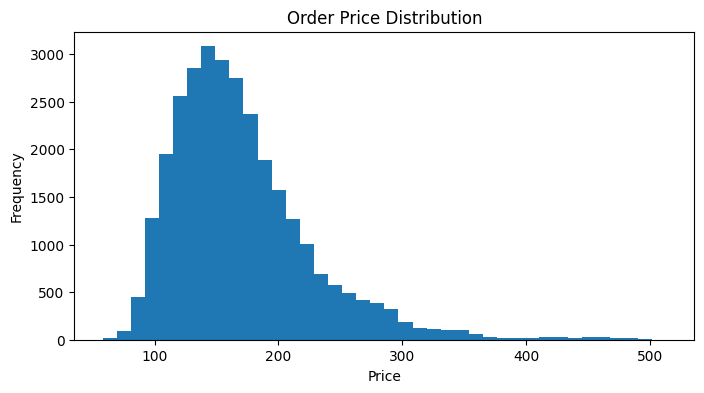

<Figure size 800x400 with 0 Axes>

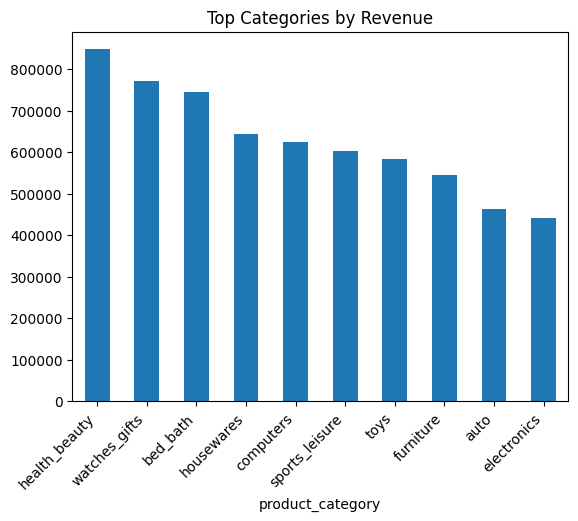

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
orders["price"].plot(kind="hist", bins=40)
plt.title("Order Price Distribution")
plt.xlabel("Price")
plt.show()

plt.figure(figsize=(8, 4))
sales_by_category.head(10).plot(
    x="product_category",
    y="revenue",
    kind="bar",
    legend=False,
)
plt.title("Top Categories by Revenue")
plt.xticks(rotation=45, ha="right")
plt.show()


## 6. Feature engineering

In [11]:
features = build_customer_features()

display(features.head())
print("Rows:", len(features))
print("Churn rate:", features["will_churn"].mean())


,customer_id,order_count,total_spend,avg_order_value,avg_freight,avg_review_score,days_since_last_purchase,future_12m_spend,future_orders,will_churn,log_total_spend
0,CUST_00001,12,2123.56,176.963333,8.612500,3.5,0,1445.03,7,0,7.661320
1,CUST_00002,12,1918.77,159.897500,9.580833,3.0,27,1905.28,12,0,7.559961
2,CUST_00003,15,3850.94,256.729333,16.179333,4.2,11,3372.77,11,0,8.256332
3,CUST_00004,13,3034.01,233.385385,11.350000,2.5,7,1852.55,10,0,8.017970
4,CUST_00005,16,3429.40,214.337500,11.819375,3.0,9,2823.70,10,0,8.140432


Rows: 1500
Churn rate: 0.18666666666666668


## 7. Classical ML

In [12]:
# Run the complete LTV and churn training pipeline.
from src.train_ml import train_models
train_models()


{
  "linear_regression_rmse": 696.3660611312591,
  "linear_regression_r2": 0.7508131825177663,
  "random_forest_rmse": 418.9598884897336,
  "random_forest_r2": 0.9098024459405715
}
{
  "knn_f1": 0.8849557522123894,
  "random_forest_f1": 0.9491525423728814
}


## 8. Read model metrics

In [13]:
import json
from src.config import REPORT_DIR

metrics = json.loads(
    (REPORT_DIR / "model_metrics.json").read_text()
)

metrics


{'dataset_rows': 1500,
 'churn_rate': 0.18666666666666668,
 'ltv': {'linear_regression_rmse': 696.3660611312591,
  'linear_regression_r2': 0.7508131825177663,
  'random_forest_rmse': 418.9598884897336,
  'random_forest_r2': 0.9098024459405715},
 'churn': {'knn_f1': 0.8849557522123894,
  'random_forest_f1': 0.9491525423728814,
  'random_forest_confusion_matrix': [[238, 6], [0, 56]],
  'random_forest_report': {'0': {'precision': 1.0,
    'recall': 0.9754098360655737,
    'f1-score': 0.9875518672199171,
    'support': 244.0},
   '1': {'precision': 0.9032258064516129,
    'recall': 1.0,
    'f1-score': 0.9491525423728814,
    'support': 56.0},
   'accuracy': 0.98,
   'macro avg': {'precision': 0.9516129032258065,
    'recall': 0.9877049180327868,
    'f1-score': 0.9683522047963993,
    'support': 300.0},
   'weighted avg': {'precision': 0.9819354838709677,
    'recall': 0.98,
    'f1-score': 0.9803839932484706,
    'support': 300.0}}}}

## 9. PyTorch deep learning

In [14]:
# Train the 5-category-history -> next-category MLP.
from src.train_dl import train
train()


Sequences: 9,040
Test accuracy: 0.886


In [15]:
# Read the DL result.
dl_history = json.loads(
    (REPORT_DIR / "dl_history.json").read_text()
)

print("Epochs:", dl_history["epochs_ran"])
print("Test accuracy:", dl_history["test_accuracy"])


Epochs: 80
Test accuracy: 0.8864306807518005


## 10. Sentiment analysis

In [16]:
from src.sentiment import analyze_reviews

analyzed_reviews = analyze_reviews(reviews)
display(
    analyzed_reviews[
        ["review_score", "review_comment_message", "sentiment", "themes"]
    ].head(20)
)


,review_score,review_comment_message,sentiment,themes
0,2,Not very happy with the purchase.,positive,[general]
1,4,Happy with the purchase and quality.,positive,[quality]
2,1,Terrible experience. The product stopped working.,negative,[quality]
3,2,Quality is below expectations.,neutral,[quality]
4,4,Happy with the purchase and quality.,positive,[quality]
5,3,It is okay for the price.,neutral,[price]
6,4,Happy with the purchase and quality.,positive,[quality]
7,3,It is okay for the price.,neutral,[price]
8,5,Excellent product. I highly recommend it.,positive,[quality]
9,2,Quality is below expectations.,neutral,[quality]


## 11. AI-powered business chatbot (ask anything)

The chatbot is now an **agent**, not a fixed set of pattern-matched questions. It is given the live database schema and the precomputed model reports, and it can call a `run_sql` tool (read-only `SELECT` statements only) to look up whatever it needs to answer correctly -- so it can handle open-ended questions the same way a ChatGPT-style analyst would, not just the handful of questions it was originally coded for.

**Setup:** `pip install anthropic` and `export ANTHROPIC_API_KEY="sk-ant-..."` before running this cell. Without a key, `answer_question` automatically falls back to a small set of offline stats (churn / reviews / sales / LTV) instead of failing.

In [ ]:
from src.chatbot import answer_question

# A mix of the original questions plus open-ended ones the old rule-based
# chatbot could never have answered -- the agent figures these out itself
# by writing and running SQL against the live database.
questions = [
    "What categories have the highest sales?",
    "What is the average review score?",
    "What is customer LTV?",
    "Why is churn high?",
    "Which 5 customers have spent the most, and what's their churn risk?",
    "How does average order value differ between 5-star and 1-star reviewers?",
    "Is revenue concentrated in a few product categories or spread evenly?",
]

history = []
for question in questions:
    print("\nQUESTION:", question)
    answer = answer_question(question, history=history)
    print("ANSWER:", answer)
    history.append({"role": "user", "content": question})
    history.append({"role": "assistant", "content": answer})


## 12. Run the Streamlit dashboard

From a terminal at the project root:

```bash
streamlit run app/streamlit_app.py
```

The dashboard combines:
- LTV prediction
- churn risk
- next-category prediction
- review sentiment/themes
- business chatbot
